In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

import os
os.makedirs('../reports/charts', exist_ok=True)


In [3]:
PROCESSED = '../data/processed/'

df_fund  = pd.read_csv(PROCESSED + '01_fund_master.csv')
df_nav   = pd.read_csv(PROCESSED + '02_nav_history.csv', parse_dates=['date'])
df_perf  = pd.read_csv(PROCESSED + '07_scheme_performance.csv')
df_bench = pd.read_csv(PROCESSED + '10_benchmark_indices.csv', parse_dates=['date'])

# Sort NAV properly
df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

print("All Data Loaded---")
print(f"  NAV records: {len(df_nav):,}")
print(f"  Fund schemes: {df_fund['amfi_code'].nunique()}")
print(f"  Benchmark records: {len(df_bench):,}")

All Data Loaded---
  NAV records: 64,320
  Fund schemes: 40
  Benchmark records: 8,050


Daily Return Statistics (all funds):
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Extreme returns (>15% in one day): 0 records


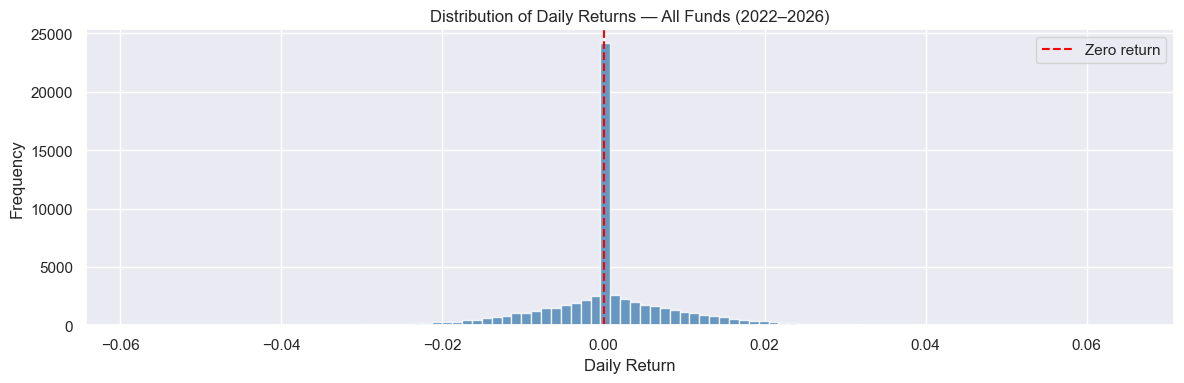

 Daily returns computed and saved


In [ ]:
# daily_return = (nav_today / nav_yesterday) - 1
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Remove first row per fund (NaN from pct_change)
df_returns = df_nav.dropna(subset=['daily_return']).copy()

# Validate distribution looks reasonable
print("Daily Return Statistics (all funds):")
print(df_returns['daily_return'].describe())
print()

# Flag extreme returns (potential data issues)
extreme = df_returns[df_returns['daily_return'].abs() > 0.15]
print(f"Extreme returns (>15% in one day): {len(extreme)} records")
if len(extreme) > 0:
    print(extreme[['amfi_code', 'date', 'nav', 'daily_return']].head(5))

# Quick distribution plot
plt.figure(figsize=(12, 4))
plt.hist(df_returns['daily_return'], bins=100, color='steelblue', 
         edgecolor='white', alpha=0.8)
plt.axvline(x=0, color='red', linestyle='--', label='Zero return')
plt.title('Distribution of Daily Returns — All Funds (2022-2026)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/charts/10_return_distribution.png', dpi=150)
plt.show()

# Save returns
df_returns.to_csv('../data/processed/returns_computed.csv', index=False)
print(" Daily returns computed and saved")

In [5]:
def compute_cagr(df_nav, amfi_code, years):
    """
    CAGR = (NAV_end / NAV_start) ^ (1/n) - 1
    n = number of years
    """
    fund_nav = df_nav[df_nav['amfi_code'] == amfi_code].sort_values('date')
    
    if len(fund_nav) < 252:  # need at least 1 year of data
        return None
    
    nav_end = fund_nav['nav'].iloc[-1]
    
    # Calculate start NAV based on years
    trading_days = int(252 * years)
    if len(fund_nav) < trading_days:
        return None
    
    nav_start = fund_nav['nav'].iloc[-trading_days]
    
    if nav_start <= 0:
        return None
    
    cagr = (nav_end / nav_start) ** (1 / years) - 1
    return round(cagr * 100, 2)  # return as percentage

# Compute for all funds
cagr_results = []

for code in df_fund['amfi_code'].unique():
    fund_name = df_fund[df_fund['amfi_code'] == code]['scheme_name'].values[0]
    fund_house = df_fund[df_fund['amfi_code'] == code]['fund_house'].values[0]
    category = df_fund[df_fund['amfi_code'] == code]['sub_category'].values[0]
    
    cagr_results.append({
        'amfi_code': code,
        'scheme_name': fund_name,
        'fund_house': fund_house,
        'sub_category': category,
        'cagr_1yr_pct': compute_cagr(df_nav, code, 1),
        'cagr_3yr_pct': compute_cagr(df_nav, code, 3),
        'cagr_5yr_pct': compute_cagr(df_nav, code, 5)
    })

df_cagr = pd.DataFrame(cagr_results)
df_cagr.to_csv('../data/processed/cagr_report.csv', index=False)

print("CAGR Summary by Sub-Category:")
print(df_cagr.groupby('sub_category')[['cagr_1yr_pct','cagr_3yr_pct','cagr_5yr_pct']].mean().round(2))
print()
print(f" CAGR computed for {len(df_cagr)} funds")

CAGR Summary by Sub-Category:
                 cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
sub_category                                             
ELSS                    40.29         20.89         18.83
Flexi Cap                8.36         19.44         19.64
Gilt                     5.21          4.24          3.37
Index                   13.98         13.11         13.16
Index/ETF               12.29         13.17         14.88
Large & Mid Cap         18.36         10.11         11.16
Large Cap               16.08         12.59         12.74
Liquid                   5.17          4.61          4.63
Mid Cap                 18.25         14.80         15.14
Short Duration           2.69          4.11          2.92
Small Cap               16.74          3.84          6.13
Value                   24.87         14.23         12.96

 CAGR computed for 40 funds


In [6]:
RISK_FREE_RATE = 0.065  # 6.5% RBI repo rate proxy
TRADING_DAYS = 252

def compute_sharpe(returns_series):
    """
    Sharpe = (Mean_daily_return - Rf_daily) / Std_daily * sqrt(252)
    Rf_daily = annual rate / 252
    """
    if len(returns_series) < 30:
        return None
    
    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    excess_return = returns_series.mean() - rf_daily
    std_return = returns_series.std()
    
    if std_return == 0:
        return None
    
    sharpe = (excess_return / std_return) * np.sqrt(TRADING_DAYS)
    return round(sharpe, 4)

# Compute Sharpe for all funds
sharpe_results = []

for code in df_fund['amfi_code'].unique():
    fund_returns = df_returns[df_returns['amfi_code'] == code]['daily_return']
    sharpe = compute_sharpe(fund_returns)
    sharpe_results.append({'amfi_code': code, 'sharpe_ratio_computed': sharpe})

df_sharpe = pd.DataFrame(sharpe_results)

# Merge with fund names
df_sharpe = df_sharpe.merge(
    df_fund[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], 
    on='amfi_code'
).sort_values('sharpe_ratio_computed', ascending=False)

print("Top 10 Funds by Sharpe Ratio:")
print(df_sharpe[['scheme_name', 'sharpe_ratio_computed', 'sub_category']].head(10).to_string())

df_sharpe.to_csv('../data/processed/sharpe_values.csv', index=False)
print(" Sharpe ratios computed")

Top 10 Funds by Sharpe Ratio:
                                           scheme_name  sharpe_ratio_computed sub_category
34       Mirae Asset Large Cap Fund - Regular - Growth                 1.0682    Large Cap
22              Kotak Flexicap Fund - Regular - Growth                 0.9656    Flexi Cap
36       Mirae Asset Tax Saver Fund - Regular - Growth                 0.9190         ELSS
12            ICICI Pru Midcap Fund - Regular - Growth                 0.8833      Mid Cap
0            SBI Bluechip Fund - Regular Plan - Growth                 0.8610    Large Cap
38                  DSP Midcap Fund - Regular - Growth                 0.8329      Mid Cap
7   HDFC Mid-Cap Opportunities Fund - Regular - Growth                 0.8083      Mid Cap
15      Nippon India Large Cap Fund - Regular - Growth                 0.7589    Large Cap
26                 Axis Midcap Fund - Regular - Growth                 0.7305      Mid Cap
28       ABSL Frontline Equity Fund - Regular - Growth      

In [7]:
def compute_sortino(returns_series):
    """
    Sortino = (Mean_return - Rf_daily) / Downside_Std * sqrt(252)
    Downside_Std = std of ONLY negative return days
    """
    if len(returns_series) < 30:
        return None
    
    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    excess_return = returns_series.mean() - rf_daily
    
    # Only negative returns
    downside_returns = returns_series[returns_series < 0]
    
    if len(downside_returns) == 0:
        return None
    
    downside_std = downside_returns.std()
    
    if downside_std == 0:
        return None
    
    sortino = (excess_return / downside_std) * np.sqrt(TRADING_DAYS)
    return round(sortino, 4)

sortino_results = []

for code in df_fund['amfi_code'].unique():
    fund_returns = df_returns[df_returns['amfi_code'] == code]['daily_return']
    sortino = compute_sortino(fund_returns)
    sortino_results.append({'amfi_code': code, 'sortino_ratio_computed': sortino})

df_sortino = pd.DataFrame(sortino_results)
df_sortino.to_csv('../data/processed/sortino_values.csv', index=False)

print("Sortino vs Sharpe comparison (top 5):")
comparison = df_sharpe.merge(df_sortino, on='amfi_code').head(5)
print(comparison[['scheme_name', 'sharpe_ratio_computed', 
                   'sortino_ratio_computed']].to_string())
print("\n Sortino ratios computed")

Sortino vs Sharpe comparison (top 5):
                                     scheme_name  sharpe_ratio_computed  sortino_ratio_computed
0  Mirae Asset Large Cap Fund - Regular - Growth                 1.0682                  1.4907
1         Kotak Flexicap Fund - Regular - Growth                 0.9656                  1.4795
2  Mirae Asset Tax Saver Fund - Regular - Growth                 0.9190                  1.3528
3       ICICI Pru Midcap Fund - Regular - Growth                 0.8833                  1.2858
4      SBI Bluechip Fund - Regular Plan - Growth                 0.8610                  1.2915

 Sortino ratios computed


In [8]:
# Get Nifty 100 returns as benchmark
nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['bench_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bench_return'])

alpha_beta_results = []

for code in df_fund['amfi_code'].unique():
    fund_returns = df_returns[df_returns['amfi_code'] == code][['date','daily_return']].copy()
    
    # Merge with benchmark on date
    merged = fund_returns.merge(
        nifty100[['date', 'bench_return']], 
        on='date', 
        how='inner'
    ).dropna()
    
    if len(merged) < 50:
        continue
    
    # OLS regression: fund_return = alpha + beta * benchmark_return
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['bench_return'],  # X = benchmark
        merged['daily_return']   # Y = fund
    )
    
    # Annualize alpha (intercept is daily)
    alpha_annual = intercept * TRADING_DAYS
    beta = slope
    
    fund_name = df_fund[df_fund['amfi_code'] == code]['scheme_name'].values[0]
    
    alpha_beta_results.append({
        'amfi_code': code,
        'scheme_name': fund_name,
        'alpha': round(alpha_annual, 4),
        'beta': round(beta, 4),
        'r_squared': round(r_value**2, 4),
        'observations': len(merged)
    })

df_alpha_beta = pd.DataFrame(alpha_beta_results)
df_alpha_beta = df_alpha_beta.merge(
    df_fund[['amfi_code', 'sub_category']], on='amfi_code'
)

df_alpha_beta.to_csv('../data/processed/alpha_beta.csv', index=False)

print("Alpha-Beta Summary:")
print(df_alpha_beta[['scheme_name', 'alpha', 'beta', 'r_squared']].to_string())
print(f"\n Alpha-Beta computed for {len(df_alpha_beta)} funds")

Alpha-Beta Summary:
                                              scheme_name   alpha    beta  r_squared
0               SBI Bluechip Fund - Regular Plan - Growth  0.2320 -0.0318     0.0009
1                SBI Bluechip Fund - Direct Plan - Growth  0.1987 -0.0262     0.0006
2              SBI Small Cap Fund - Regular Plan - Growth  0.3034 -0.0232     0.0001
3               SBI Small Cap Fund - Direct Plan - Growth  0.0488  0.0620     0.0010
4            SBI Magnum Gilt Fund - Regular Plan - Growth  0.0562 -0.0064     0.0004
5               HDFC Top 100 Fund - Regular Plan - Growth  0.0375 -0.0583     0.0027
6                HDFC Top 100 Fund - Direct Plan - Growth  0.1773  0.0488     0.0018
7      HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.2720  0.0051     0.0000
8       HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.1199  0.0091     0.0000
9            HDFC Short Term Debt Fund - Regular - Growth  0.0428  0.0012     0.0000
10             ICICI Pru Bluechip Fund - Regu

In [9]:
def compute_max_drawdown(nav_series):
    """
    Max Drawdown = min(NAV / running_max - 1)
    Running max = highest NAV seen up to that point
    """
    rolling_max = nav_series.expanding().max()
    drawdown = nav_series / rolling_max - 1
    max_dd = drawdown.min()
    max_dd_date = drawdown.idxmin()
    return round(max_dd * 100, 2), max_dd_date

drawdown_results = []

for code in df_fund['amfi_code'].unique():
    fund_nav = df_nav[df_nav['amfi_code'] == code].sort_values('date')
    
    if len(fund_nav) < 30:
        continue
    
    fund_nav_indexed = fund_nav.set_index('date')['nav']
    max_dd, max_dd_date = compute_max_drawdown(fund_nav_indexed)
    fund_name = df_fund[df_fund['amfi_code'] == code]['scheme_name'].values[0]
    
    drawdown_results.append({
        'amfi_code': code,
        'scheme_name': fund_name,
        'max_drawdown_pct_computed': max_dd,
        'worst_date': max_dd_date
    })

df_drawdown = pd.DataFrame(drawdown_results).sort_values('max_drawdown_pct_computed')

print("Worst Drawdowns (most negative = worst):")
print(df_drawdown[['scheme_name','max_drawdown_pct_computed','worst_date']].head(10).to_string())

df_drawdown.to_csv('../data/processed/max_drawdown.csv', index=False)
print("\n Max Drawdown computed")

Worst Drawdowns (most negative = worst):
                                       scheme_name  max_drawdown_pct_computed worst_date
3        SBI Small Cap Fund - Direct Plan - Growth                     -52.57 2025-10-28
27          Axis Small Cap Fund - Regular - Growth                     -51.68 2026-05-11
29          ABSL Small Cap Fund - Regular - Growth                     -35.45 2026-05-11
39           DSP Small Cap Fund - Regular - Growth                     -31.17 2025-01-03
2       SBI Small Cap Fund - Regular Plan - Growth                     -28.71 2025-05-14
32             UTI Mid Cap Fund - Regular - Growth                     -28.00 2026-04-27
5        HDFC Top 100 Fund - Regular Plan - Growth                     -24.73 2022-09-15
21   Kotak Emerging Equity Fund - Regular - Growth                     -24.00 2024-10-17
17  Nippon India Small Cap Fund - Regular - Growth                     -23.34 2026-02-20
25            Axis Bluechip Fund - Direct - Growth                   

In [10]:
# Merge all metrics
df_scorecard = df_fund[['amfi_code', 'scheme_name', 'fund_house', 
                          'sub_category', 'expense_ratio_pct']].copy()

df_scorecard = df_scorecard.merge(df_cagr[['amfi_code','cagr_3yr_pct']], 
                                    on='amfi_code', how='left')
df_scorecard = df_scorecard.merge(df_sharpe[['amfi_code','sharpe_ratio_computed']], 
                                    on='amfi_code', how='left')
df_scorecard = df_scorecard.merge(df_alpha_beta[['amfi_code','alpha']], 
                                    on='amfi_code', how='left')
df_scorecard = df_scorecard.merge(df_drawdown[['amfi_code','max_drawdown_pct_computed']], 
                                    on='amfi_code', how='left')

df_scorecard = df_scorecard.dropna()

# Rank each metric (higher rank = better)
# For expense ratio and drawdown — LOWER is better (inverse rank)
n = len(df_scorecard)

df_scorecard['rank_3yr_return']  = df_scorecard['cagr_3yr_pct'].rank(ascending=True)
df_scorecard['rank_sharpe']       = df_scorecard['sharpe_ratio_computed'].rank(ascending=True)
df_scorecard['rank_alpha']        = df_scorecard['alpha'].rank(ascending=True)
df_scorecard['rank_expense']      = df_scorecard['expense_ratio_pct'].rank(ascending=False)  # inverse
df_scorecard['rank_drawdown']     = df_scorecard['max_drawdown_pct_computed'].rank(ascending=False)  # inverse

# Composite Score = weighted sum of ranks normalized to 0-100
df_scorecard['composite_score'] = (
    0.30 * df_scorecard['rank_3yr_return'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_drawdown']
)

# Normalize to 0-100
min_score = df_scorecard['composite_score'].min()
max_score = df_scorecard['composite_score'].max()
df_scorecard['score_0_100'] = ((df_scorecard['composite_score'] - min_score) / 
                                 (max_score - min_score) * 100).round(1)

df_scorecard = df_scorecard.sort_values('score_0_100', ascending=False)

print(" TOP 10 FUNDS — COMPOSITE SCORECARD:")
print(df_scorecard[['scheme_name', 'score_0_100', 'cagr_3yr_pct', 
                      'sharpe_ratio_computed', 'alpha']].head(10).to_string())

df_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
print("\n Fund scorecard saved")

 TOP 10 FUNDS — COMPOSITE SCORECARD:
                                           scheme_name  score_0_100  cagr_3yr_pct  sharpe_ratio_computed   alpha
7   HDFC Mid-Cap Opportunities Fund - Regular - Growth        100.0         24.41                 0.8083  0.2720
34       Mirae Asset Large Cap Fund - Regular - Growth         99.2         25.13                 1.0682  0.2698
12            ICICI Pru Midcap Fund - Regular - Growth         97.7         15.72                 0.8833  0.2926
22              Kotak Flexicap Fund - Regular - Growth         97.5         21.67                 0.9656  0.2733
2           SBI Small Cap Fund - Regular Plan - Growth         95.8         18.93                 0.7117  0.3034
26                 Axis Midcap Fund - Regular - Growth         95.0         21.29                 0.7305  0.2608
0            SBI Bluechip Fund - Regular Plan - Growth         92.8         28.56                 0.8610  0.2320
39               DSP Small Cap Fund - Regular - Growth     

In [11]:
# Top 5 funds by scorecard
top5_codes = df_scorecard['amfi_code'].head(5).tolist()
top5_names = df_scorecard.set_index('amfi_code')['scheme_name'].to_dict()

# Get 3 years of data
cutoff_date = pd.Timestamp('2023-01-01')

fig = go.Figure()

# Plot top 5 funds (normalized to 100 at start)
for code in top5_codes:
    fund_nav = df_nav[
        (df_nav['amfi_code'] == code) & 
        (df_nav['date'] >= cutoff_date)
    ].sort_values('date')
    
    if len(fund_nav) < 100:
        continue
    
    # Normalize: start at 100
    normalized = (fund_nav['nav'] / fund_nav['nav'].iloc[0]) * 100
    
    fig.add_trace(go.Scatter(
        x=fund_nav['date'],
        y=normalized,
        mode='lines',
        name=top5_names.get(code, str(code))[:30],
        line=dict(width=2)
    ))

# Plot Nifty 50 benchmark
nifty50 = df_bench[
    (df_bench['index_name'] == 'NIFTY50') & 
    (df_bench['date'] >= cutoff_date)
].sort_values('date')

nifty50_norm = (nifty50['close_value'] / nifty50['close_value'].iloc[0]) * 100

fig.add_trace(go.Scatter(
    x=nifty50['date'],
    y=nifty50_norm,
    mode='lines',
    name='Nifty 50 (Benchmark)',
    line=dict(color='white', width=3, dash='dash')
))

# Plot Nifty 100 benchmark
nifty100_chart = df_bench[
    (df_bench['index_name'] == 'NIFTY100') & 
    (df_bench['date'] >= cutoff_date)
].sort_values('date')

nifty100_norm = (nifty100_chart['close_value'] / nifty100_chart['close_value'].iloc[0]) * 100

fig.add_trace(go.Scatter(
    x=nifty100_chart['date'],
    y=nifty100_norm,
    mode='lines',
    name='Nifty 100 (Benchmark)',
    line=dict(color='yellow', width=3, dash='dot')
))

fig.update_layout(
    title='Top 5 Funds vs Nifty 50 and Nifty 100 (3 Year, Normalized to 100)',
    xaxis_title='Date',
    yaxis_title='Normalized Value (Start = 100)',
    template='plotly_dark',
    height=600,
    legend=dict(font=dict(size=10))
)

fig.write_image('../reports/charts/11_benchmark_comparison.png', scale=2)
fig.show()

# Compute tracking error for each fund vs Nifty 50
print("\nTracking Error vs Nifty 50:")
for code in top5_codes:
    fund_ret = df_returns[df_returns['amfi_code'] == code][['date','daily_return']]
    merged_te = fund_ret.merge(nifty50[['date','close_value']], on='date')
    merged_te['bench_return'] = merged_te['close_value'].pct_change()
    merged_te = merged_te.dropna()
    
    if len(merged_te) > 30:
        tracking_error = (merged_te['daily_return'] - merged_te['bench_return']).std() * np.sqrt(252)
        name = top5_names.get(code, str(code))[:35]
        print(f"  {name}: {tracking_error:.4f} ({tracking_error*100:.2f}%)")

print("\n Benchmark comparison complete")


Tracking Error vs Nifty 50:
  HDFC Mid-Cap Opportunities Fund - R: 0.2266 (22.66%)
  Mirae Asset Large Cap Fund - Regula: 0.1921 (19.21%)
  ICICI Pru Midcap Fund - Regular - G: 0.2305 (23.05%)
  Kotak Flexicap Fund - Regular - Gro: 0.2051 (20.51%)
  SBI Small Cap Fund - Regular Plan -: 0.2791 (27.91%)

 Benchmark comparison complete


In [12]:
print("=" * 60)
print(" DAY 4: FUND PERFORMANCE ANALYTICS COMPLETE")
print("=" * 60)
print()
print("Files saved to data/processed/:")
files = ['returns_computed.csv', 'cagr_report.csv', 
         'sharpe_values.csv', 'sortino_values.csv',
         'alpha_beta.csv', 'max_drawdown.csv', 'fund_scorecard.csv']

for f in files:
    path = f'../data/processed/{f}'
    if os.path.exists(path):
        rows = len(pd.read_csv(path))
        print(f"   -{f} ({rows} rows)")

print()
print("Charts saved:")
print("    10_return_distribution.png")
print("    11_benchmark_comparison.png")


 DAY 4: FUND PERFORMANCE ANALYTICS COMPLETE

Files saved to data/processed/:
   -returns_computed.csv (64280 rows)
   -cagr_report.csv (40 rows)
   -sharpe_values.csv (40 rows)
   -sortino_values.csv (40 rows)
   -alpha_beta.csv (40 rows)
   -max_drawdown.csv (40 rows)
   -fund_scorecard.csv (40 rows)

Charts saved:
    10_return_distribution.png
    11_benchmark_comparison.png
